# LLM-Guided Tree Search Experiment

Traverse the ICD10h hierarchy with a local LLM (Qwen2.5-7B-Instruct) using beam search
to map historical cause-of-death strings to ICD10h codes.

Dataset: Belgian SOSA 1920-1930 records (single-CoD subset).

In [1]:
# Cell 1: Imports + Config
from __future__ import annotations

import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd

# Make project root importable
PROJECT_ROOT = Path.cwd().parents[1]
for p in [str(PROJECT_ROOT / "src"), str(PROJECT_ROOT)]:
    if p not in sys.path:
        sys.path.insert(0, p)

from codllm.config import DataSourceConfig
from codllm.data_handler import BELGIUM_MAPPING, load_source_dataset
from experiments.tree_search.icd10h_tree import build_tree, tree_stats
from experiments.tree_search.tree_search import (
    LLMClient,
    TreeSearchConfig,
    beam_search,
    evaluate_search_results,
    search_batch,
)

# --- Paths ---
MASTERLIST_PATH = PROJECT_ROOT / "data" / "ICD10h_Masterlist_2024.xlsx"

# --- Parameters ---
SEED = 42
SAMPLE_FRAC = 0.05  # start small; increase once validated
np.random.seed(SEED)

# --- Tree search config ---
config = TreeSearchConfig(
    beam_width=3,
    top_choices=3,
    retry_count=1,
    llm_base_url="http://localhost:1234/v1",   # LM Studio
    llm_model="qwen2.5-7b-instruct",
    llm_temperature=0.1,
    llm_max_tokens=512,
)

print(f"Project root: {PROJECT_ROOT}")
print(f"Beam width:   {config.beam_width}")
print(f"Top choices:  {config.top_choices}")
print(f"LLM endpoint: {config.llm_base_url}")
print(f"LLM model:    {config.llm_model}")

Project root: c:\Users\edlun\Desktop\DTU\Bachelor\codLLM
Beam width:   3
Top choices:  3
LLM endpoint: http://localhost:1234/v1
LLM model:    qwen2.5-7b-instruct


In [2]:
# Cell 2: Load Belgian data — single-CoD records only
belgium_source = DataSourceConfig(
    source_id="belgium_1920_1930",
    path="SOSA_EXTR_1920-1930 (belgium).xlsx",
    mapping_id="belgium",
)

df_all = load_source_dataset(
    source=belgium_source,
    mapping=BELGIUM_MAPPING,
    training_input=["cod"],
    max_labels=6,
    data_raw_dir=str(PROJECT_ROOT / "data" / "raw"),
)

# Strip "cod: " prefix
df_all["query"] = df_all["text"].str.replace(r"^cod:\s*", "", regex=True)

# Filter to single-code records
df_single = df_all[df_all["y_codes"].apply(len) == 1].copy()
df_single["gold_code"] = df_single["y_codes"].apply(lambda x: x[0])

print(f"Total records:       {len(df_all):,}")
print(f"Single-code records: {len(df_single):,} ({len(df_single)/len(df_all)*100:.1f}%)")
print(f"Multi-code records:  {len(df_all) - len(df_single):,}")

# Subsample
df_sample = df_single.sample(frac=SAMPLE_FRAC, random_state=SEED).reset_index(drop=True)
print(f"\nSample size ({SAMPLE_FRAC*100:.0f}%): {len(df_sample):,}")
df_sample[["record_id", "query", "gold_code"]].head(10)

Total records:       42,115
Single-code records: 35,287 (83.8%)
Multi-code records:  6,828

Sample size (5%): 1,764


,record_id,query,gold_code
0,922A1991,Long tering,A16.200
1,921A2252,Sénilité,R54.000
2,930A0099,Cancer de l'estomac,C16.901
3,924A2828,Sénilité,R54.000
4,923A1005,Rougeole,B05.900
5,920A3034,Apoplexie cérébrale,I71.900
6,928A2617,Pleurésie,R09.100
7,922A0347,Diabète,E14.000
8,922A1321,Hartziekte,I51.900
9,929A0090,Asystolie,I46.900


## Ground truth distribution across tree levels

Before running the search, let's see how concentrated or spread out the gold codes are.
If most records map to a handful of chapters/blocks, the LLM's job is easier;
if they're spread thin, beam search has more room to go wrong.

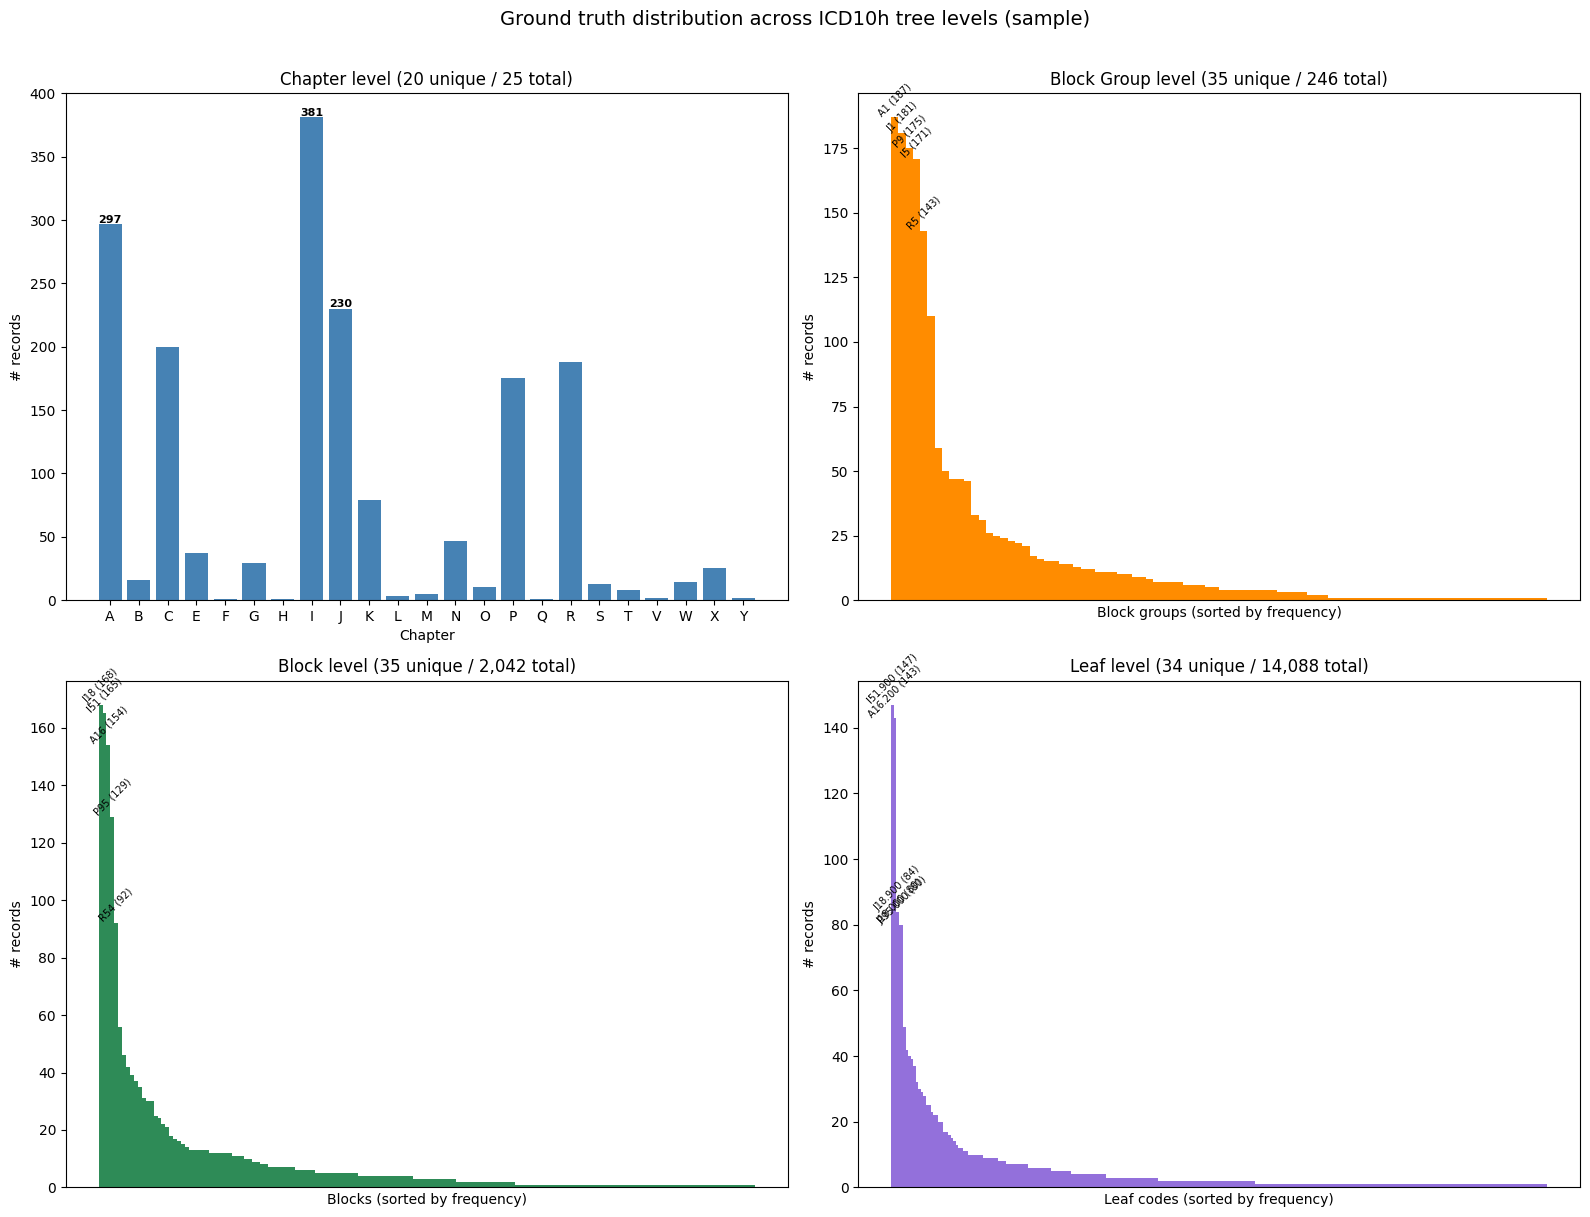


Concentration summary:
  Chapter       :   20 unique | top-1 =  16.8% | top-5 =  31.2% | top-10 =  72.1%
  Block Group   :   35 unique | top-1 =  10.6% | top-5 =  48.6% | top-10 =  66.3%
  Block         :   35 unique | top-1 =   9.5% | top-5 =  40.1% | top-10 =  52.6%
  Leaf          :   34 unique | top-1 =   8.3% | top-5 =  30.3% | top-10 =  42.0%


In [3]:
# Cell 2b: Gold code distribution per tree level
import matplotlib.pyplot as plt

gold = df_sample["gold_code"]
df_sample["gold_chapter"] = gold.str[0]
df_sample["gold_block_group"] = gold.str[:2]
df_sample["gold_block"] = gold.str[:3]
df_sample["gold_category"] = gold.str[:5]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Chapter level ---
ch_counts = df_sample["gold_chapter"].value_counts().sort_index()
ax = axes[0, 0]
bars = ax.bar(ch_counts.index, ch_counts.values, color="steelblue")
ax.set_title(f"Chapter level ({ch_counts.nunique()} unique / 25 total)")
ax.set_xlabel("Chapter")
ax.set_ylabel("# records")
# Annotate top 3
for idx in ch_counts.nlargest(3).index:
    val = ch_counts[idx]
    ax.text(list(ch_counts.index).index(idx), val + 1, str(val), ha="center", fontsize=8, fontweight="bold")

# --- Block Group level ---
bg_counts = df_sample["gold_block_group"].value_counts()
ax = axes[0, 1]
ax.bar(range(len(bg_counts)), bg_counts.values, color="darkorange", width=1.0)
ax.set_title(f"Block Group level ({bg_counts.nunique()} unique / 246 total)")
ax.set_xlabel(f"Block groups (sorted by frequency)")
ax.set_ylabel("# records")
ax.set_xticks([])
# Annotate top 5
for i, (bg, cnt) in enumerate(bg_counts.head(5).items()):
    ax.text(i, cnt + 0.5, f"{bg} ({cnt})", ha="center", fontsize=7, rotation=45)

# --- Block level ---
blk_counts = df_sample["gold_block"].value_counts()
ax = axes[1, 0]
ax.bar(range(len(blk_counts)), blk_counts.values, color="seagreen", width=1.0)
ax.set_title(f"Block level ({blk_counts.nunique()} unique / 2,042 total)")
ax.set_xlabel(f"Blocks (sorted by frequency)")
ax.set_ylabel("# records")
ax.set_xticks([])
for i, (blk, cnt) in enumerate(blk_counts.head(5).items()):
    ax.text(i, cnt + 0.5, f"{blk} ({cnt})", ha="center", fontsize=7, rotation=45)

# --- Leaf level ---
leaf_counts = gold.value_counts()
ax = axes[1, 1]
ax.bar(range(len(leaf_counts)), leaf_counts.values, color="mediumpurple", width=1.0)
ax.set_title(f"Leaf level ({leaf_counts.nunique()} unique / 14,088 total)")
ax.set_xlabel(f"Leaf codes (sorted by frequency)")
ax.set_ylabel("# records")
ax.set_xticks([])
for i, (code, cnt) in enumerate(leaf_counts.head(5).items()):
    ax.text(i, cnt + 0.3, f"{code} ({cnt})", ha="center", fontsize=7, rotation=45)

plt.suptitle("Ground truth distribution across ICD10h tree levels (sample)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# --- Summary table ---
print("\nConcentration summary:")
for name, counts in [("Chapter", ch_counts), ("Block Group", bg_counts),
                      ("Block", blk_counts), ("Leaf", leaf_counts)]:
    top1_pct = counts.iloc[0] / counts.sum() * 100
    top5_pct = counts.head(5).sum() / counts.sum() * 100
    top10_pct = counts.head(10).sum() / counts.sum() * 100
    print(f"  {name:<14s}: {counts.nunique():>4d} unique | "
          f"top-1 = {top1_pct:5.1f}% | top-5 = {top5_pct:5.1f}% | top-10 = {top10_pct:5.1f}%")

In [4]:
# Cell 3: Build ICD10h tree
print("Building ICD10h tree...")
t0 = time.time()
tree = build_tree(MASTERLIST_PATH)
build_time = time.time() - t0

stats = tree_stats(tree)
print(f"Build time: {build_time:.1f}s\n")
print("Tree statistics:")
for k, v in stats.items():
    print(f"  {k:>25s}: {v:,}")

Building ICD10h tree...
Build time: 10.4s

Tree statistics:
                       root: 1
                    chapter: 25
                block_group: 246
                      block: 2,042
                   category: 10,555
                       leaf: 14,088
                total_nodes: 26,957
       max_branching_factor: 25


In [5]:
# Cell 4: Initialize LLM client + smoke test
llm = LLMClient(config)

# Quick smoke test with one query
test_cod = df_sample["query"].iloc[0]
test_gold = df_sample["gold_code"].iloc[0]
print(f"Smoke test: '{test_cod}' (gold: {test_gold})")

t0 = time.time()
test_result = beam_search(test_cod, tree, llm, config)
t1 = time.time()

print(f"Time: {t1-t0:.1f}s | LLM calls: {test_result.llm_calls}")
print(f"Predictions: {test_result.predictions}")
print(f"Gold in predictions: {test_gold in test_result.predictions}")
print(f"\nTrace:")
for i, trace in enumerate(test_result.traces):
    print(f"  Beam {i}: {' → '.join(code for code, _ in trace)}")

Smoke test: 'Long tering' (gold: A16.200)


All LLM attempts failed, falling back to first 3 options
All LLM attempts failed, falling back to first 3 options
All LLM attempts failed, falling back to first 3 options
All LLM attempts failed, falling back to first 3 options
All LLM attempts failed, falling back to first 3 options
All LLM attempts failed, falling back to first 3 options


Time: 35.4s | LLM calls: 9
Predictions: ['J00.000', 'J01.000', 'J01.100']
Gold in predictions: False

Trace:
  Beam 0: J → J0 → J00 → J00.0 → J00.000
  Beam 1: J → J0 → J01 → J01.0 → J01.000
  Beam 2: J → J0 → J01 → J01.1 → J01.100


In [6]:
# Cell 5: Run tree search on full sample (with checkpointing)
queries = df_sample["query"].tolist()
gold_codes = df_sample["gold_code"].tolist()

CHECKPOINT_PATH = PROJECT_ROOT / "data" / "cache" / "tree_search" / "checkpoint.pkl"
CHECKPOINT_EVERY = 50  # save every 50 records

print(f"Running tree search on {len(queries)} queries...")
print(f"Config: beam_width={config.beam_width}, top_choices={config.top_choices}")
print(f"Checkpoint: {CHECKPOINT_PATH} (every {CHECKPOINT_EVERY} records)")
print(f"Tip: Ctrl+C to stop — progress is saved and will resume on re-run.")
print()

t0 = time.time()
results = search_batch(
    queries, tree, llm, config,
    progress=True,
    checkpoint_path=CHECKPOINT_PATH,
    checkpoint_every=CHECKPOINT_EVERY,
)
total_time = time.time() - t0

print(f"\nDone: {len(results)}/{len(queries)} records in {total_time:.1f}s")
print(f"Total LLM calls: {sum(r.llm_calls for r in results):,}")
print(f"Total tokens: {llm.total_tokens:,}")

Running tree search on 1764 queries...
Config: beam_width=3, top_choices=3
Checkpoint: c:\Users\edlun\Desktop\DTU\Bachelor\codLLM\data\cache\tree_search\checkpoint.pkl (every 50 records)
Tip: Ctrl+C to stop — progress is saved and will resume on re-run.



Tree search:   0%|          | 0/1764 [00:00<?, ?it/s]All LLM attempts failed, falling back to first 3 options
All LLM attempts failed, falling back to first 3 options
All LLM attempts failed, falling back to first 3 options
All LLM attempts failed, falling back to first 3 options
All LLM attempts failed, falling back to first 3 options
All LLM attempts failed, falling back to first 3 options
Tree search:   0%|          | 1/1764 [00:32<15:46:11, 32.20s/it]All LLM attempts failed, falling back to first 3 options
All LLM attempts failed, falling back to first 3 options
All LLM attempts failed, falling back to first 3 options
All LLM attempts failed, falling back to first 3 options
All LLM attempts failed, falling back to first 3 options
All LLM attempts failed, falling back to first 3 options
All LLM attempts failed, falling back to first 3 options
All LLM attempts failed, falling back to first 3 options
All LLM attempts failed, falling back to first 3 options
All LLM attempts failed, fal


Interrupted after 7 / 1764 records.
Checkpoint saved to c:\Users\edlun\Desktop\DTU\Bachelor\codLLM\data\cache\tree_search\checkpoint.pkl

Done: 7/1764 records in 262.6s
Total LLM calls: 70
Total tokens: 75,870


In [ ]:
# Cell 6: Evaluate Recall@K (works on partial results too)
n_done = len(results)
gold_subset = gold_codes[:n_done]

eval_df = evaluate_search_results(results, gold_subset, k_values=[1, 3, 5])

print("=" * 50)
print(f"Tree Search Results — Recall@K  ({n_done}/{len(queries)} records)")
print("=" * 50)
display(eval_df)

# Per-prediction stats
n_with_predictions = sum(1 for r in results if r.predictions)
avg_predictions = np.mean([len(r.predictions) for r in results])
avg_calls = np.mean([r.llm_calls for r in results])

print(f"\nRecords with >=1 prediction: {n_with_predictions}/{n_done}")
print(f"Avg predictions per record:  {avg_predictions:.1f}")
print(f"Avg LLM calls per record:    {avg_calls:.1f}")
if n_done > 0:
    print(f"Avg time per record:         {total_time/n_done:.2f}s")

In [ ]:
# Cell 7: Inspect random examples with traces
rng = np.random.RandomState(SEED)
sample_idx = rng.choice(len(results), size=min(5, len(results)), replace=False)

for idx in sample_idx:
    r = results[idx]
    gold = gold_codes[idx]
    hit = gold in r.predictions
    status = "HIT" if hit else "MISS"
    
    print("=" * 80)
    print(f"[{status}] Query: {r.cod_string}")
    print(f"Gold: {gold} | Predictions: {r.predictions} | LLM calls: {r.llm_calls}")
    print(f"Traces:")
    for i, trace in enumerate(r.traces):
        path_str = " → ".join(f"{code} ({label[:30]})" for code, label in trace)
        print(f"  Beam {i}: {path_str}")
    print()

In [ ]:
# Cell 8: Error analysis — inspect misses
misses = [
    (i, results[i], gold_codes[i])
    for i in range(len(results))
    if gold_codes[i] not in results[i].predictions
]

print(f"Total misses: {len(misses)} / {len(results)} ({len(misses)/len(results)*100:.1f}%)")
print()

# Show first 10 misses
for idx, r, gold in misses[:10]:
    print(f"  Query: {r.cod_string:<40s} | Gold: {gold} | Got: {r.predictions}")

# Analyze where misses diverge from gold path
print("\n--- Miss depth analysis ---")
gold_chapters = [g[0] for _, _, g in misses]
pred_chapters = [
    r.traces[0][0][0] if r.traces else "?" for _, r, _ in misses
]
chapter_match = sum(1 for gc, pc in zip(gold_chapters, pred_chapters) if gc == pc)
print(f"Chapter correct: {chapter_match}/{len(misses)} ({chapter_match/max(len(misses),1)*100:.1f}%)")

In [ ]:
# Cell 9: Speed statistics
total_calls = sum(r.llm_calls for r in results)

print("Speed Statistics")
print("=" * 40)
print(f"  Total records:     {len(results):,}")
print(f"  Total time:        {total_time:.1f}s ({total_time/60:.1f}m)")
print(f"  Avg per record:    {total_time/len(results):.2f}s")
print(f"  Total LLM calls:   {total_calls:,}")
print(f"  Avg calls/record:  {total_calls/len(results):.1f}")
print(f"  Avg time/LLM call: {total_time/max(total_calls,1)*1000:.0f}ms")
print(f"  Total tokens:      {llm.total_tokens:,}")
print(f"\nProjected time for full dataset ({len(df_single):,} records):")
print(f"  {total_time/len(results)*len(df_single)/3600:.1f} hours")

In [ ]:
# Cell 10: Save artifacts
OUT_DIR = PROJECT_ROOT / "data" / "cache" / "tree_search"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Build results dataframe
results_rows = []
for i, r in enumerate(results):
    results_rows.append({
        "query": r.cod_string,
        "gold_code": gold_codes[i],
        "predictions": r.predictions,
        "llm_calls": r.llm_calls,
        "hit_at_1": gold_codes[i] in r.predictions[:1],
        "hit_at_3": gold_codes[i] in r.predictions[:3],
    })

results_df = pd.DataFrame(results_rows)
results_df.to_pickle(OUT_DIR / "results.pkl")
eval_df.to_csv(OUT_DIR / "recall_at_k.csv", index=False)

print(f"Saved to {OUT_DIR}")
print(f"  results.pkl      ({len(results_df)} records)")
print(f"  recall_at_k.csv")